In [1]:
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

In [2]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nTarget Distribution:")
print(df["Class"].value_counts())

print("\nTarget Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Dataset Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values:
0

Target Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Target Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


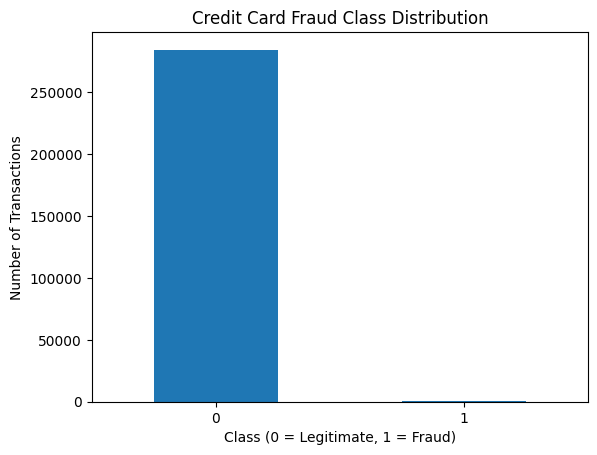

In [4]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")

plt.title("Credit Card Fraud Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

In [5]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [7]:
!pip install -q imbalanced-learn

In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [9]:
!pip install -q xgboost

In [10]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [11]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [12]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("First 10 predicted probabilities:")
print(y_prob[:10])

print("\nFirst 10 predictions:")
print(y_pred[:10])

First 10 predicted probabilities:
[1.9445311e-05 1.9620260e-05 2.5958591e-06 6.4495259e-07 5.2550243e-04
 2.8911383e-05 3.6543126e-06 7.9084339e-06 2.8133260e-05 7.6052006e-06]

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [13]:
from sklearn.metrics import roc_auc_score, classification_report

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.9814

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.87      0.81        98

    accuracy                           1.00     56962
   macro avg       0.88      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



Confusion Matrix:
[[56837    27]
 [   13    85]]


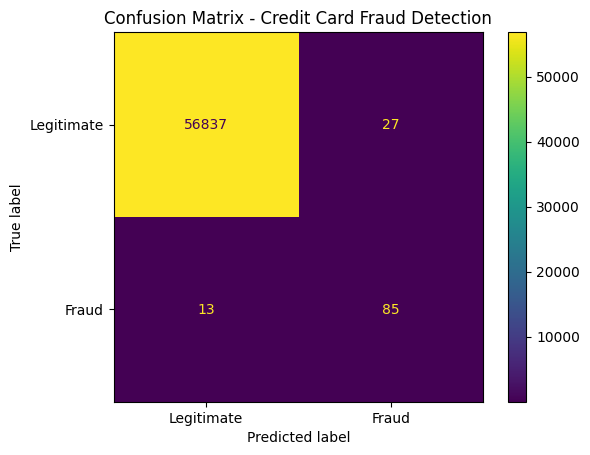

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Credit Card Fraud Detection")
plt.show()

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")


Threshold: 0.1
Precision: 0.4751
Recall:    0.8776
F1-score:  0.6165

Threshold: 0.2
Precision: 0.6014
Recall:    0.8776
F1-score:  0.7137

Threshold: 0.3
Precision: 0.6538
Recall:    0.8673
F1-score:  0.7456

Threshold: 0.4
Precision: 0.7143
Recall:    0.8673
F1-score:  0.7834

Threshold: 0.5
Precision: 0.7589
Recall:    0.8673
F1-score:  0.8095


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
V14       0.621172
V10       0.068540
V4        0.062464
V12       0.034385
V17       0.017767
V8        0.015934
V3        0.015212
V1        0.014547
V13       0.011485
V9        0.009911
V21       0.009743
V7        0.008825
V16       0.007886
V26       0.007663
Amount    0.007536
dtype: float32


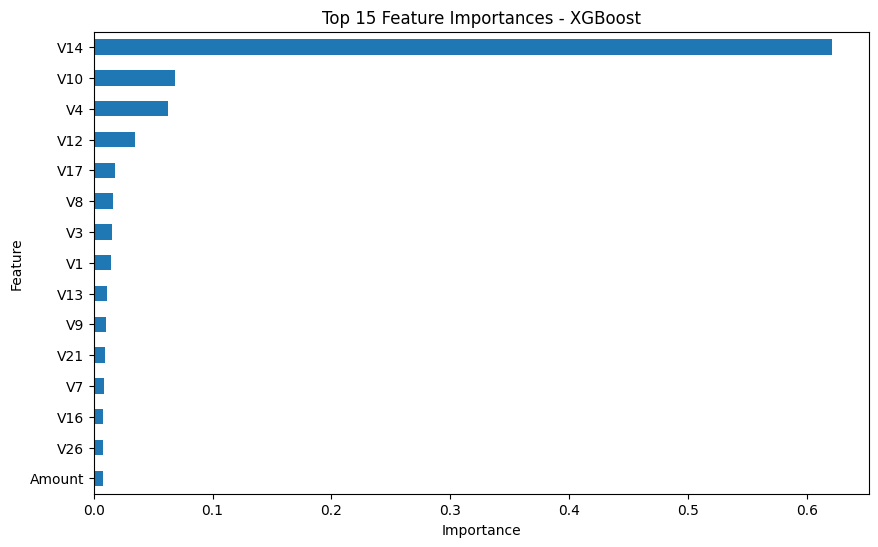

In [17]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [18]:
print("===== Credit Card Fraud Detection - Final Summary =====")
print(f"Dataset Shape: {df.shape}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nModel: XGBoost")
print("Imbalance Handling: SMOTE")
print("Threshold Tuning: 0.1 to 0.5")
print("Feature Importance: XGBoost")

===== Credit Card Fraud Detection - Final Summary =====
Dataset Shape: (284807, 31)
ROC-AUC: 0.9814

Model: XGBoost
Imbalance Handling: SMOTE
Threshold Tuning: 0.1 to 0.5
Feature Importance: XGBoost
